#### Importing Necessary Libraries

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

#### Load Excel into DataFrame

In [50]:
df = pd.read_excel("data/premiums_young_with_gr.xlsx")
rows, col = df.shape
print(f"Total number of rows are {rows} and columns are {col}")

Total number of rows are 20096 and columns are 14


In [51]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount,Genetical_Risk
count,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000
mean,21.494029,0.718004,22.506519,8141.941033,2.503881
std,2.294050,0.940767,23.418644,2749.609551,1.710115
min,18.000000,-3.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.000000,1.000000
50%,21.500000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


In [52]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount', 'Genetical_Risk'],
      dtype='object')

In [53]:
df.columns = df.columns.str.lower().str.replace(" ","_")
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk'],
      dtype='object')

#### Treating Null Values

In [54]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [55]:
df = df.dropna() 
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

#### Treating Duplicates Rows

In [56]:
df.duplicated().sum()
df = df.drop_duplicates()

#### Treating Outliers

In [57]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267,2.503932
std,2.294052,0.940713,23.420493,2749.906347,1.710203
min,18.000000,-3.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


In [58]:
df[df.number_of_dependants<0].shape

(22, 14)

In [59]:
df['number_of_dependants'] = df['number_of_dependants'].abs()
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.722598,22.510851,8142.096267,2.503932
std,2.294052,0.937200,23.420493,2749.906347,1.710203
min,18.000000,0.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


#### Boxplot for Numeric Columns

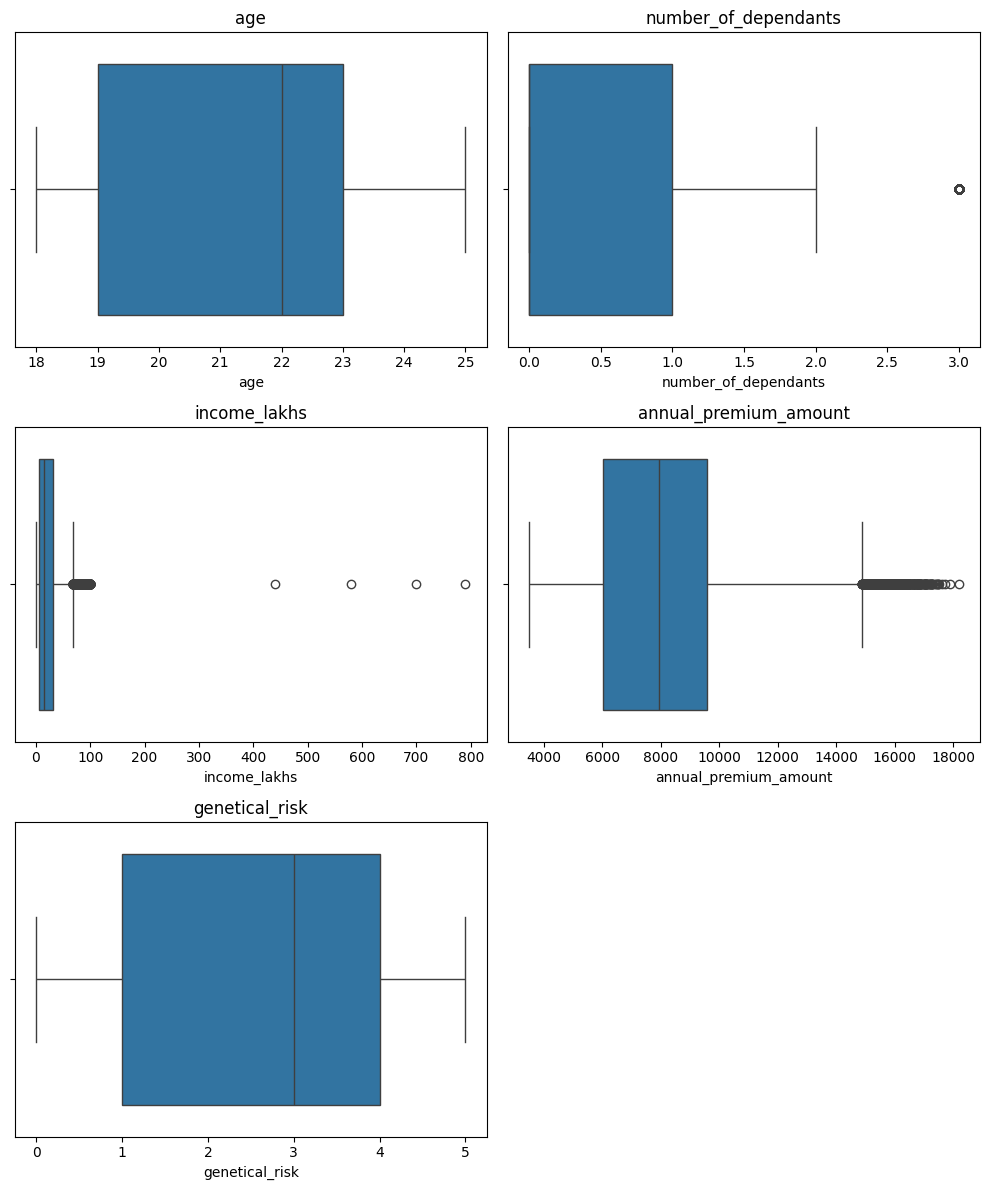

In [60]:
numeric_col = df.select_dtypes(include='number').columns
n_cols = 2  # Number of plots per row
n_rows = math.ceil(len(numeric_col) / n_cols)

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(numeric_col, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### Histogram for Income column

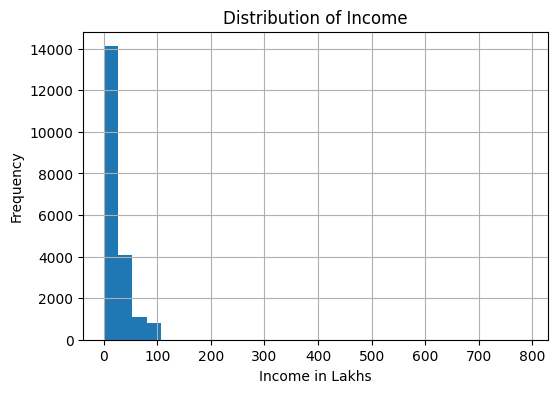

In [61]:
df['income_lakhs'].hist(bins=30, figsize=(6,4))
plt.title("Distribution of Income")
plt.xlabel("Income in Lakhs")
plt.ylabel("Frequency")
plt.show()

#### Outlier Removal using IQR

In [62]:
def iqr_cal(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [63]:
upper, lower = iqr_cal('income_lakhs')
print(upper, lower)

-31.5 68.5


In [64]:
quantile_threshold = df.income_lakhs.quantile(0.999)
quantile_threshold

np.float64(100.0)

In [65]:
df = df[df['income_lakhs']<quantile_threshold]
df[df['income_lakhs']>100]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk


#### Histogram for Numeric Columns

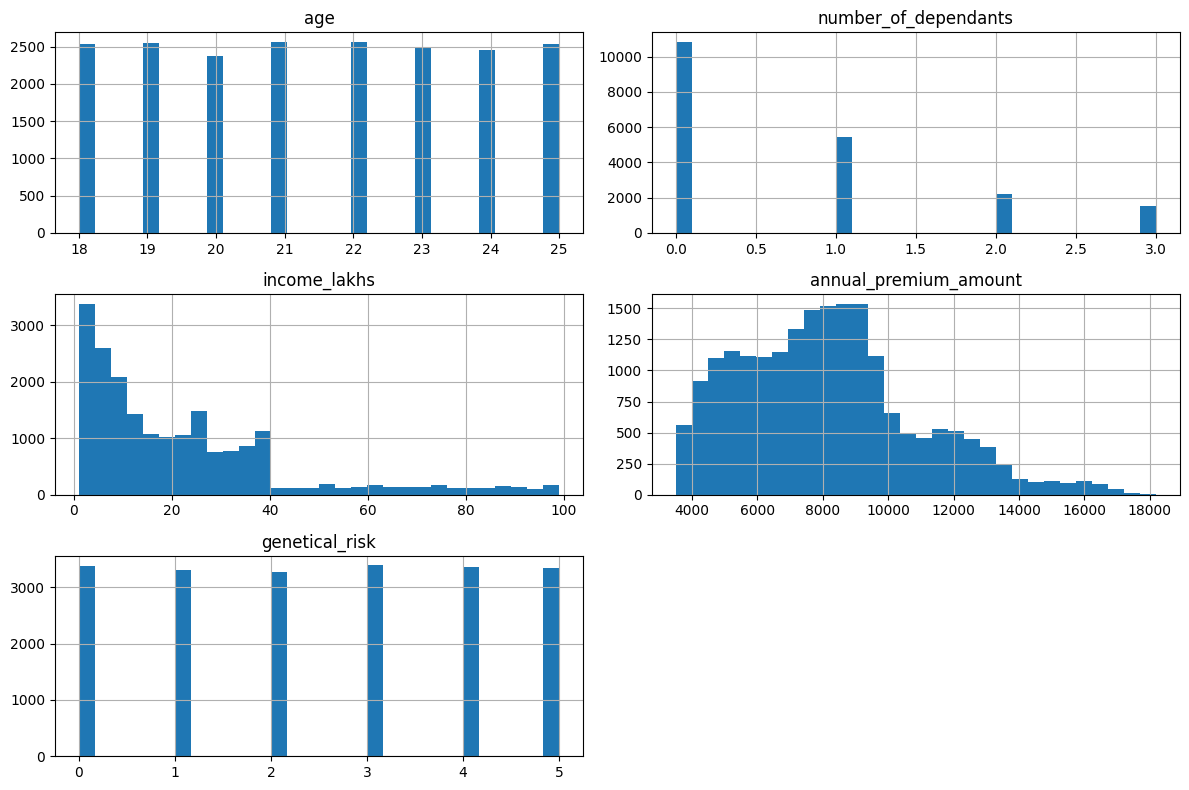

In [66]:
df.hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

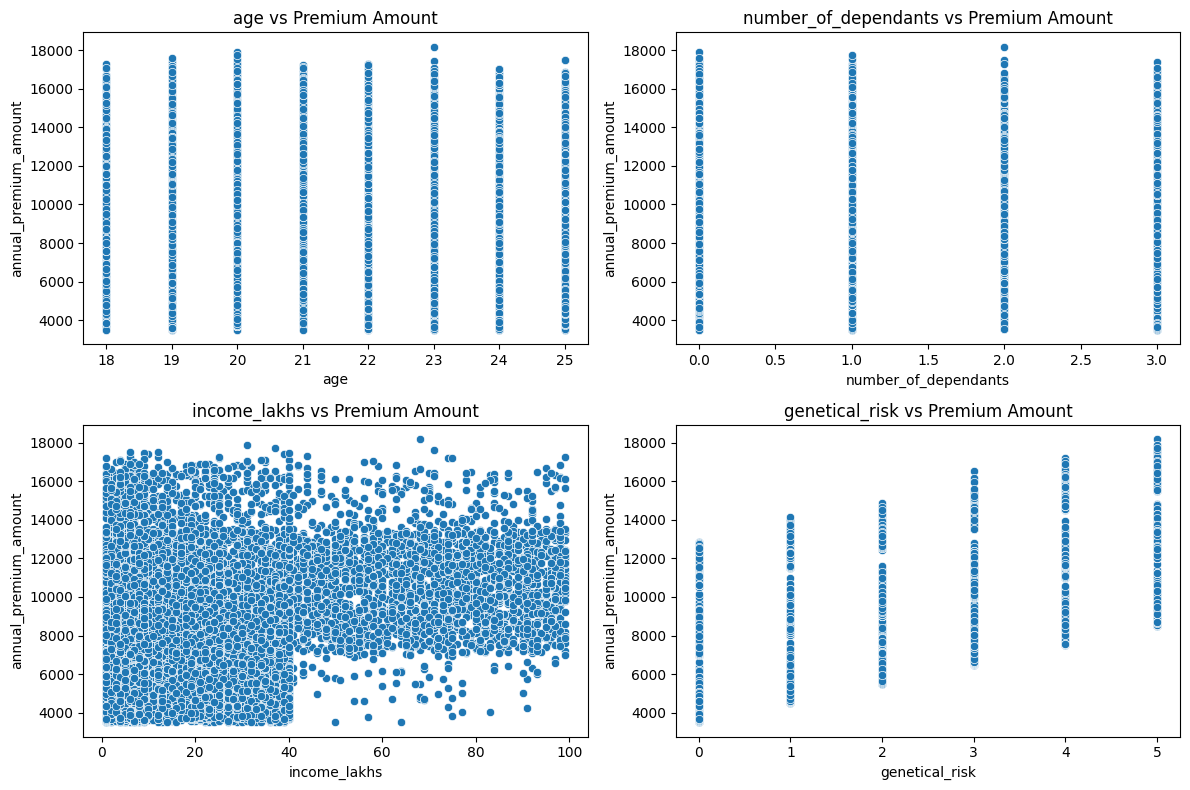

In [67]:
# num_col = numeric_col
num_col = numeric_col.drop('annual_premium_amount')  # remove target

n_cols = 2
n_rows = math.ceil(len(num_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.scatterplot(x=df[col], y=df['annual_premium_amount'], ax=axes[i])
    axes[i].set_title(f"{col} vs Premium Amount")

# Remove extra empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Outlier Removal in Categorical Column

In [68]:
cat_col = df.select_dtypes(include='object').columns
cat_col

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [69]:
for col in cat_col:
    print(f"{col}:{df[col].unique()}")

gender:['Male' 'Female']
region:['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status:['Unmarried' 'Married']
bmi_category:['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status:['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status:['Self-Employed' 'Freelancer' 'Salaried']
income_level:['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history:['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan:['Silver' 'Bronze' 'Gold']


In [70]:
df['smoking_status'] = df['smoking_status'].replace(
    ['Smoking=0', 'Does Not Smoke', 'Not Smoking'],
    'No Smoking')

In [71]:
for col in cat_col:
    print(f"{col}:{df[col].unique()}")

gender:['Male' 'Female']
region:['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status:['Unmarried' 'Married']
bmi_category:['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status:['Regular' 'No Smoking' 'Occasional']
employment_status:['Self-Employed' 'Freelancer' 'Salaried']
income_level:['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history:['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan:['Silver' 'Bronze' 'Gold']


In [72]:
df['gender'].value_counts()

gender
Male      11037
Female     9017
Name: count, dtype: int64

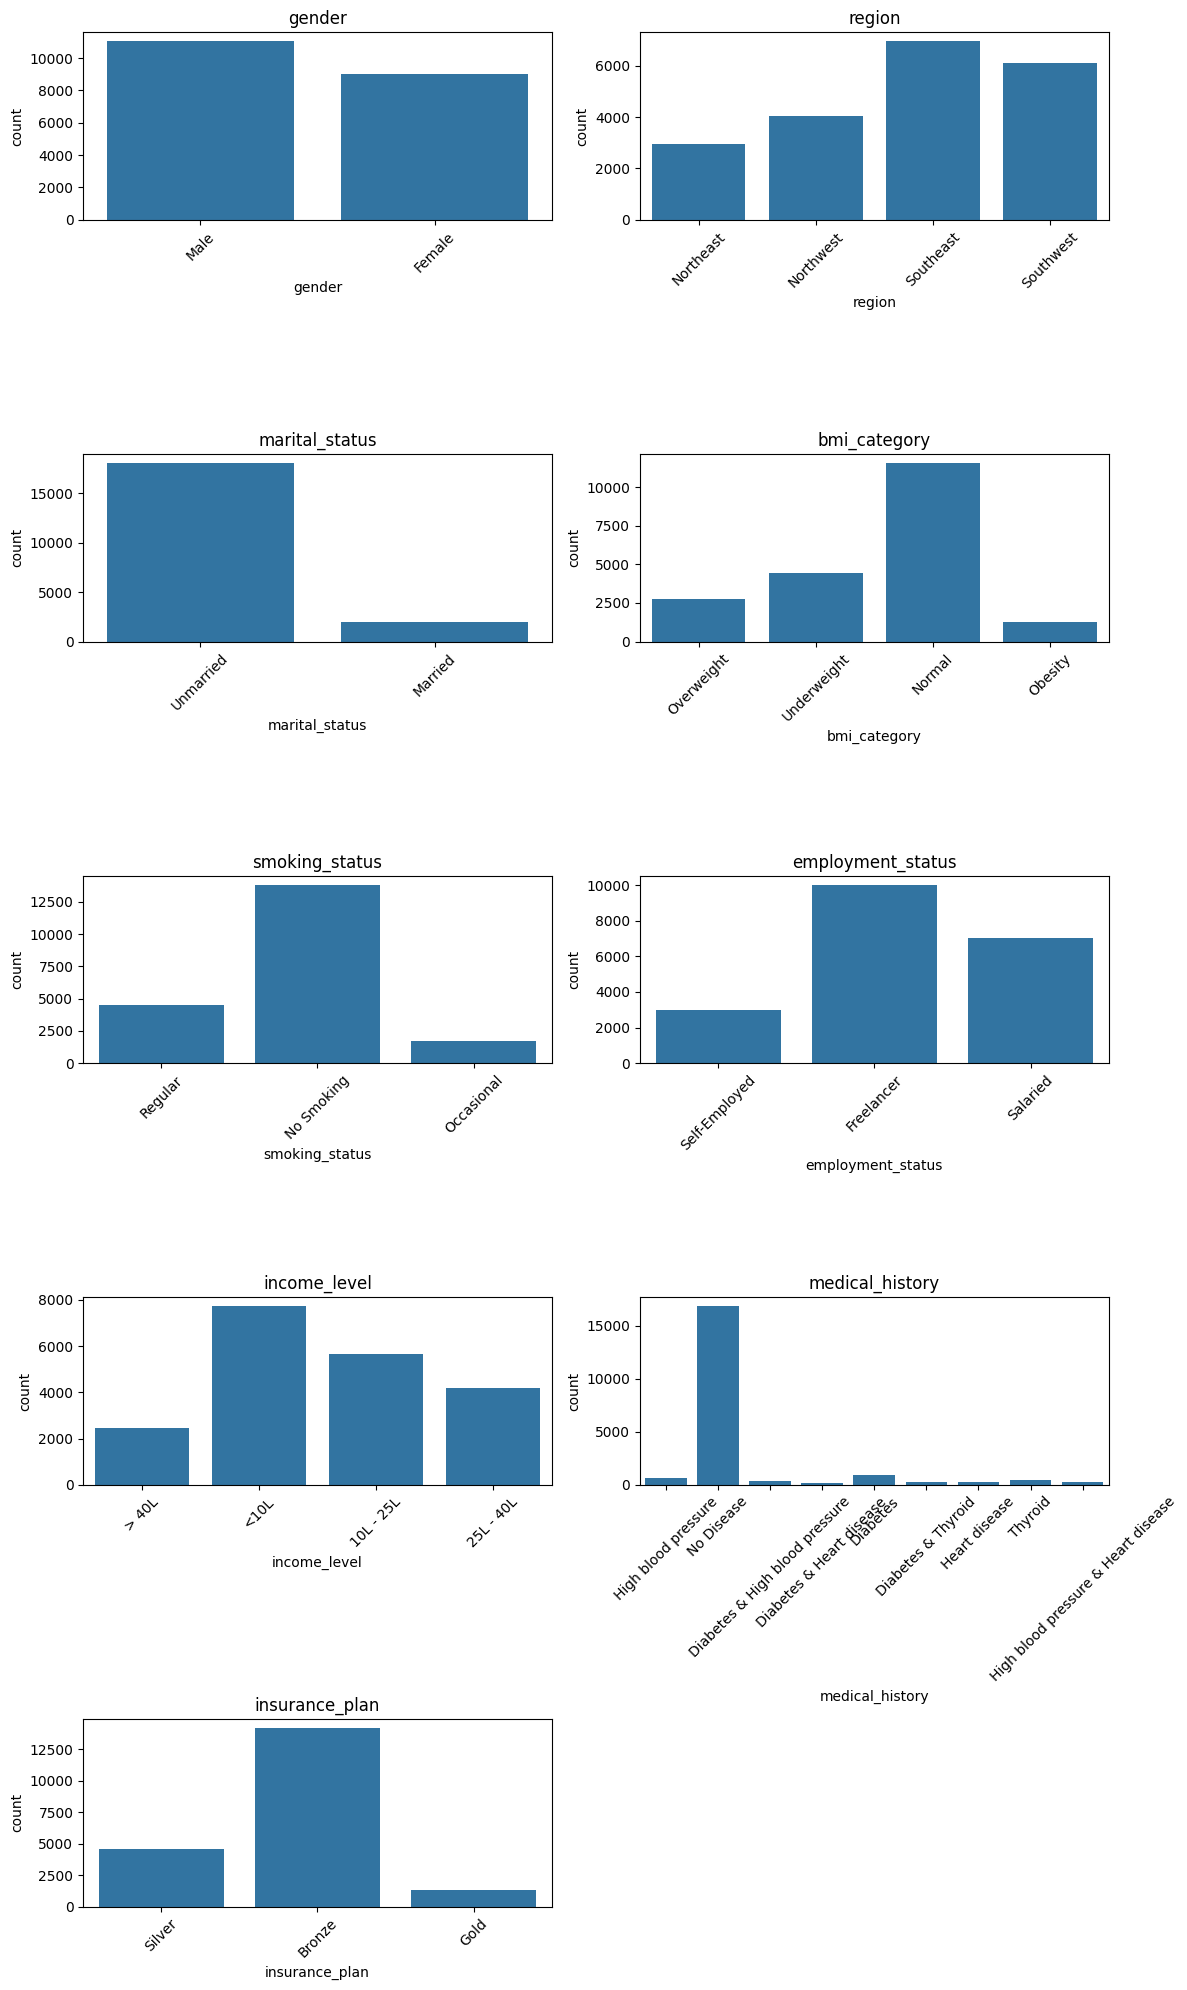

In [73]:
n_cols = 2
n_rows = math.ceil(len(cat_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove extra empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Bi-Variate Analysis

In [74]:
pd.crosstab(df['income_level'], df['insurance_plan'])

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,4508,326,828
25L - 40L,3382,209,608
<10L,6172,404,1145
> 40L,115,362,1995


#### Feature Engineering

In [75]:
df.medical_history.unique()

array(['High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Diabetes & Heart disease',
       'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
       'High blood pressure & Heart disease'], dtype=object)

In [76]:
risk_scores = {
    'diabetes':6,
    'heart disease':8,
    'high blood pressure':6,
    'no disease':0,
    'thyroid':5,
    'none':0
}

In [77]:
df[['disease1','disease2']] = df['medical_history'].str.split("&", expand=True).apply(lambda x:x.str.lower().str.strip())

In [78]:
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4,high blood pressure,None
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3,no disease,None
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4,no disease,None
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2,no disease,None
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1,no disease,None


In [79]:
df['disease1'].fillna('none', inplace=True)
df['disease2'].fillna('none', inplace=True)
df.head()
invalid_rows = df[~df['disease1'].isin(risk_scores.keys())]
invalid_rows

C:\Users\yogesh\AppData\Local\Temp\ipykernel_9456\3574473948.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['disease1'].fillna('none', inplace=True)
C:\Users\yogesh\AppData\Local\Temp\ipykernel_9456\3574473948.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2


In [80]:
df['total_risk_score'] = 0

for disease in ['disease1','disease2']:
    df['total_risk_score'] += df[disease].map(risk_scores)
max_score = df['total_risk_score'].max()
min_score = df['total_risk_score'].min()
df['normalized_risk_score'] = (df['total_risk_score'] - min_score )/(max_score - min_score)
df.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score,normalized_risk_score
2027,19,Male,Northwest,Unmarried,0,Underweight,Regular,Freelancer,10L - 25L,10,No Disease,Bronze,4404,0,no disease,none,0,0.000000
7475,21,Male,Northeast,Unmarried,0,Overweight,No Smoking,Self-Employed,> 40L,58,Heart disease,Gold,13997,1,heart disease,none,8,0.571429
15756,21,Female,Southeast,Unmarried,2,Obesity,No Smoking,Salaried,<10L,8,No Disease,Bronze,6813,2,no disease,none,0,0.000000
5044,25,Male,Southeast,Unmarried,1,Overweight,Regular,Freelancer,25L - 40L,38,No Disease,Bronze,8679,4,no disease,none,0,0.000000
11481,24,Female,Southwest,Unmarried,2,Overweight,No Smoking,Freelancer,<10L,1,No Disease,Bronze,8487,4,no disease,none,0,0.000000


In [81]:
df.insurance_plan.unique()

array(['Silver', 'Bronze', 'Gold'], dtype=object)

In [82]:
df['insurance_plan'] = df['insurance_plan'].map({'Bronze':1, 'Silver':2, 'Gold':3})
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,2,13365,4,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,2,11050,3,no disease,none,0,0.000000
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,2,11857,4,no disease,none,0,0.000000
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,1,5684,2,no disease,none,0,0.000000
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,1,5712,1,no disease,none,0,0.000000


In [83]:
df.insurance_plan.unique()

array([2, 1, 3])

In [84]:
df['income_level'].unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L'], dtype=object)

In [85]:
df['income_level'] = df['income_level'].map({'<10L':1, '10L - 25L':2, '> 40L':4, '25L - 40L':3})
df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,4,99,High blood pressure,2,13365,4,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,1,3,No Disease,2,11050,3,no disease,none,0,0.000000


In [86]:
df['income_level'].unique()

array([4, 1, 2, 3])

In [87]:
nominal_cols = ['gender','region','marital_status','bmi_category','smoking_status','employment_status']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)
df.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,4,high blood pressure,none,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,3,no disease,none,...,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,No Disease,2,11857,4,no disease,none,...,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,No Disease,1,5684,2,no disease,none,...,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,No Disease,1,5712,1,no disease,none,...,1,0,1,0,1,0,0,0,0,0


In [88]:
df = df.drop(['medical_history','disease1','disease2','total_risk_score'],axis=1)

In [89]:
df.head(2)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,4,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,3,0.000000,0,1,0,0,1,0,0,1,0,0,0,0


#### Correlation

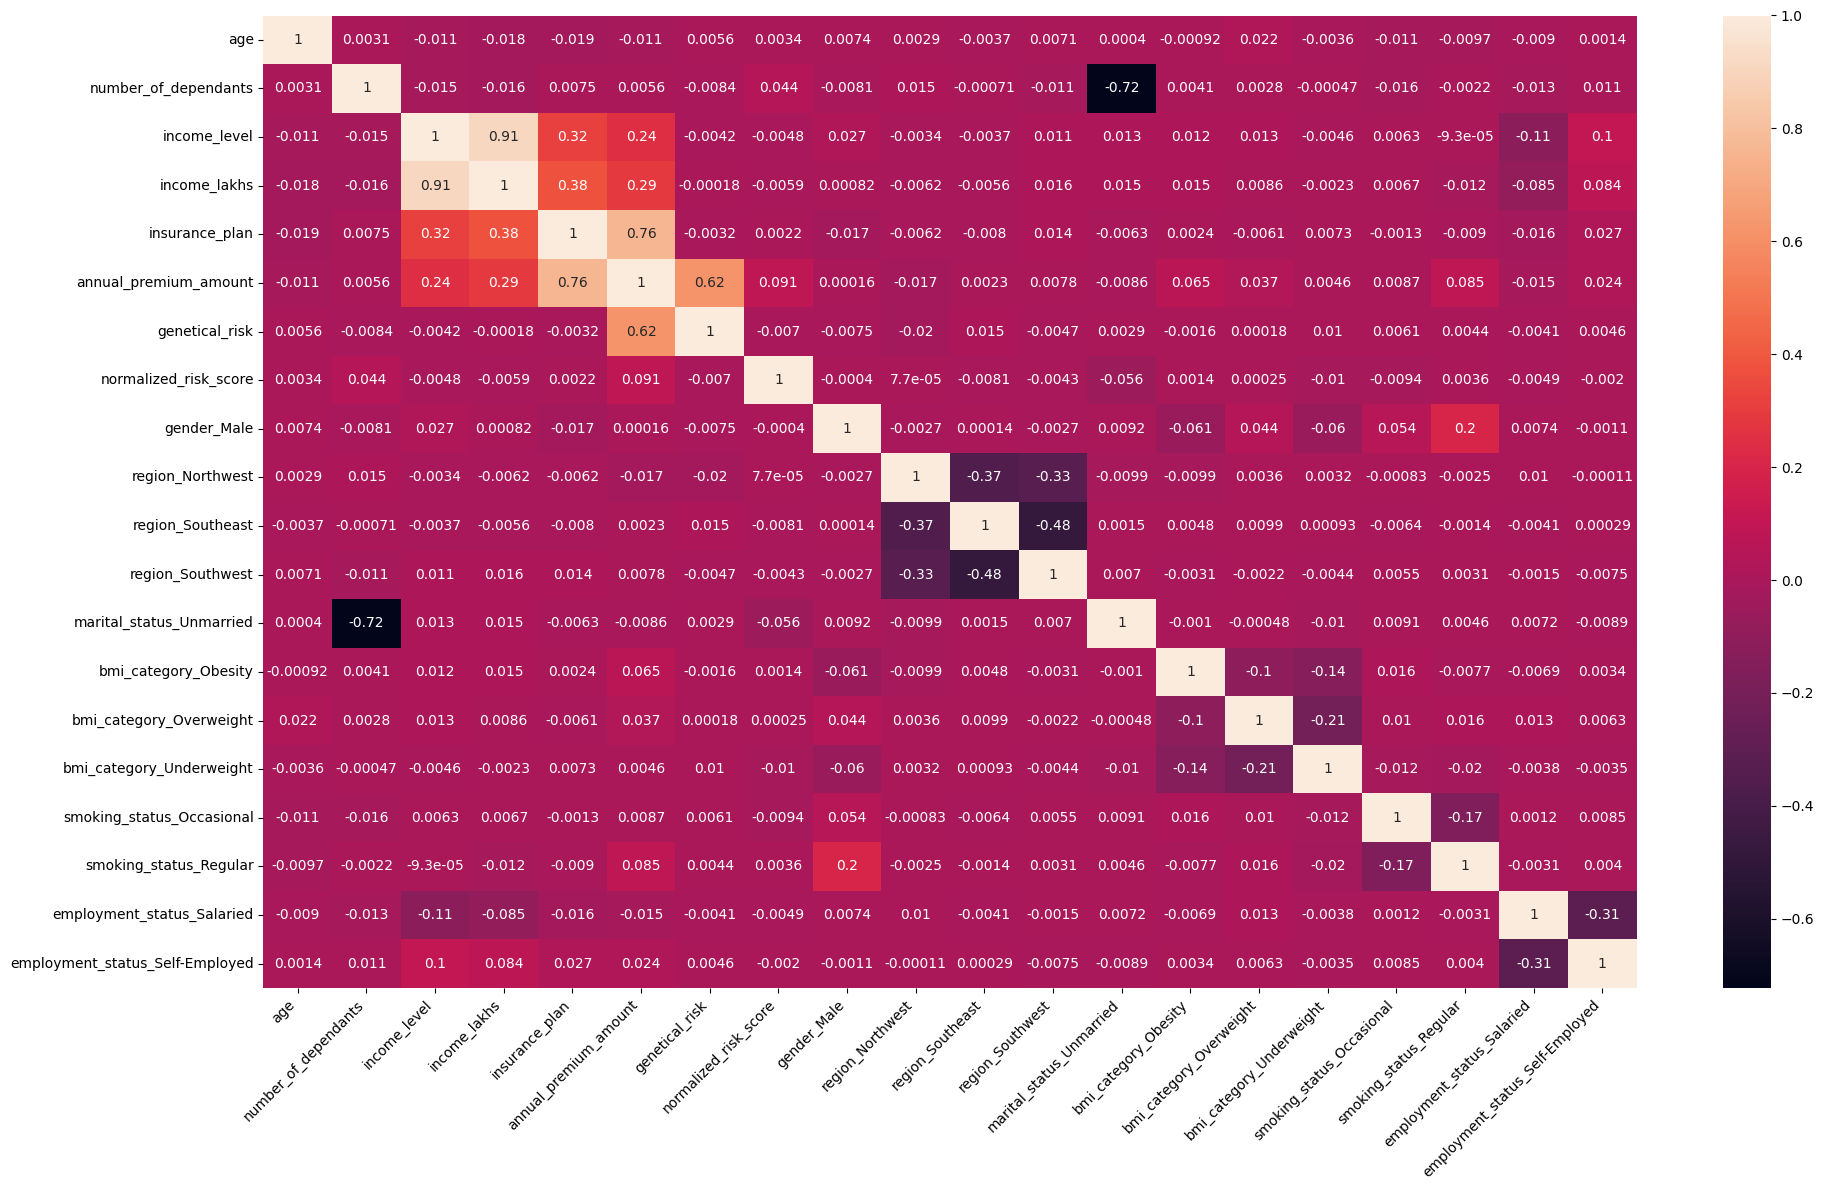

In [90]:
cm = df.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [91]:
df.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'genetical_risk',
       'normalized_risk_score', 'gender_Male', 'region_Northwest',
       'region_Southeast', 'region_Southwest', 'marital_status_Unmarried',
       'bmi_category_Obesity', 'bmi_category_Overweight',
       'bmi_category_Underweight', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

In [92]:
X = df.drop('annual_premium_amount', axis=1)
y = df['annual_premium_amount']
cols_to_scale = ['age','income_level','income_lakhs','insurance_plan','number_of_dependants','genetical_risk']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,1.000000,0.5,0.8,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.000000,0.020408,0.5,0.6,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,1.000000,0.979592,0.5,0.8,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.333333,0.142857,0.0,0.4,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.333333,0.132653,0.0,0.2,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


In [93]:
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000
mean,0.499145,0.240816,0.356970,0.217005,0.178967,0.500648,0.092130,0.550364,0.201306,0.346863,0.304578,0.899920,0.063528,0.136531,0.222300,0.086417,0.223497,0.350155,0.149945
std,0.327769,0.312344,0.346809,0.219663,0.299827,0.342048,0.230059,0.497469,0.400987,0.475984,0.460240,0.300114,0.243917,0.343360,0.415802,0.280985,0.416599,0.477030,0.357027
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142857,0.000000,0.000000,0.051020,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.428571,0.000000,0.333333,0.153061,0.000000,0.600000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.714286,0.333333,0.666667,0.306122,0.500000,0.800000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Calculating VIF

In [94]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [95]:
calculate_vif(X)

,Column,VIF
0,age,3.154003
1,number_of_dependants,1.929843
2,income_level,12.076236
3,income_lakhs,12.066070
4,insurance_plan,1.587040
5,genetical_risk,2.979519
6,normalized_risk_score,1.154598
7,gender_Male,2.311741
8,region_Northwest,2.153798
9,region_Southeast,2.988985


In [96]:
calculate_vif(X.drop('income_level',axis=1))

,Column,VIF
0,age,3.152594
1,number_of_dependants,1.927345
2,income_lakhs,2.295899
3,insurance_plan,1.581741
4,genetical_risk,2.979517
5,normalized_risk_score,1.154563
6,gender_Male,2.301517
7,region_Northwest,2.152910
8,region_Southeast,2.987812
9,region_Southwest,2.743533


In [97]:
X_reduced = X.drop('income_level',axis=1)
X_reduced.head()

,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,0.5,0.8,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.020408,0.5,0.6,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,0.979592,0.5,0.8,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.142857,0.0,0.4,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.132653,0.0,0.2,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


#### Model Training

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=10)

print("X train: ",X_train.shape)
print("X test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

X train:  (14037, 18)
X test:  (6017, 18)
y train:  (14037,)
y test:  (6017,)


In [99]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
r2_train = model_lr.score(X_train, y_train)
# y_pred = model_lr.predict(X_test)
r2_test = model_lr.score(X_test, y_test)

r2_test, r2_train

(0.9883024425745823, 0.9884613429334488)

In [100]:
model_lr.intercept_

np.float64(3997.399023656866)

In [101]:
model_lr.coef_

array([-6.07009916e+00,  5.05214522e+00, -7.45274752e+00,  7.00494096e+03,
        4.99109246e+03,  1.11479443e+03,  4.93797939e+00,  6.51640518e+00,
       -3.84458025e+00,  5.55789282e+00, -2.91905776e+00,  8.10591557e+02,
        4.07171235e+02,  1.10207314e+02,  2.00886429e+02,  6.12475040e+02,
       -1.25939895e+00, -7.52704515e+00])

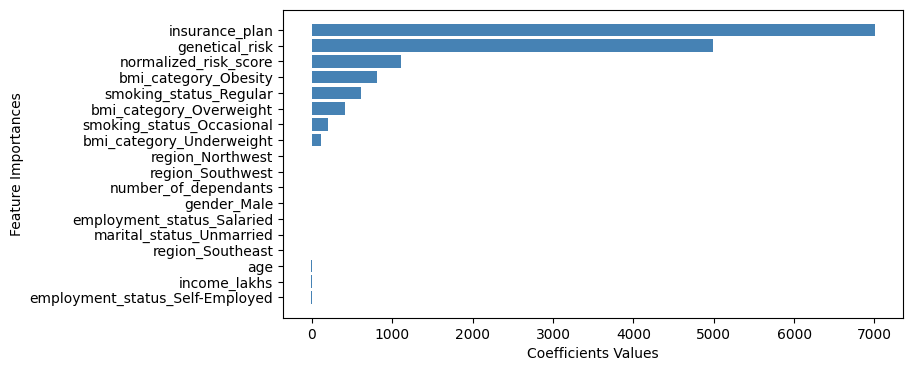

In [102]:
feature_importances = model_lr.coef_
coef_df = pd.DataFrame(feature_importances, index=X_test.columns, columns=['Coefficients'])
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8,4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficients Values')
plt.ylabel('Feature Importances')
plt.show()

In [103]:
model_rg = Ridge()
model_rg.fit(X_train, y_train)
r2_train = model_rg.score(X_train, y_train)
# y_pred = model_rg.predict(X_test)
r2_test = model_rg.score(X_test, y_test)

r2_test, r2_train

(0.9883039072751133, 0.9884607375019715)

In [123]:
best_model = model_lr

In [125]:
# feature_importances = best_model.feature_importances_
# coef_df = pd.DataFrame(feature_importances, index=X_test.columns, columns=['Coefficients'])
# coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# plt.figure(figsize=(8,4))
# plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
# plt.xlabel('Coefficients Values')
# plt.ylabel('Feature Importances')
# plt.show()

#### Error Analysis

In [110]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = residuals*100/y_test
results_df = pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residuals,
    'diff_pct':residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
1710,4096,4380.654297,284.654297,6.949568
11963,4503,4383.353027,-119.646973,-2.657050
8719,8332,8145.791992,-186.208008,-2.234854
7208,11578,11481.032227,-96.967773,-0.837517
9416,7045,6985.416992,-59.583008,-0.845749


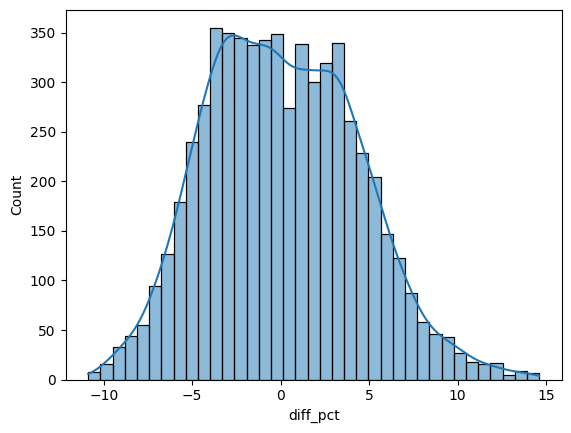

In [111]:
sns.histplot(results_df['diff_pct'],kde=True)
plt.show()

In [112]:
extreme_error_threshold = 10
extreme_results_df = results_df[np.abs(results_df.diff_pct)>extreme_error_threshold]
extreme_results_df.shape


(104, 4)

In [113]:
extreme_error_pct = extreme_results_df.shape[0]*100/results_df.shape[0]
extreme_error_pct

1.728436097723118

In [126]:
results_df[np.abs(results_df.diff_pct)>10].sort_values('diff_pct', ascending=False)

,actual,predicted,diff,diff_pct
17197,3508,4020.237793,512.237793,14.601990
10165,3501,4008.902344,507.902344,14.507351
18500,3508,4015.843994,507.843994,14.476739
7299,3505,4008.902344,503.902344,14.376672
4964,3906,4455.466797,549.466797,14.067250
...,...,...,...,...
18548,4572,4089.486816,-482.513184,-10.553657
4495,4589,4104.563965,-484.436035,-10.556462
2796,4570,4074.874268,-495.125732,-10.834261
17370,4599,4099.680664,-499.319336,-10.857128


In [115]:
X_test.index

Index([ 1710, 11963,  8719,  7208,  9416, 15637,  6511, 11179,  7608,  6396,
       ...
       18017, 17253,  5619, 20068,  3065,  2154, 11201, 18574, 17354, 10020],
      dtype='int64', length=6017)

In [116]:
extreme_results_df.index

Index([ 1835, 12285,  1812,  7758, 16580, 14074,  4226,  3396,  1986, 10038,
       ...
         355, 14412,  6552, 18892,  7912, 11302,  7991, 10165, 18017, 18574],
      dtype='int64', length=104)

In [117]:
extreme_error_df = X_test.loc[extreme_results_df.index]
extreme_error_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
1835,0.714286,0.000000,0.030612,0.0,0.2,0.0,1,0,0,1,1,0,0,0,0,0,0,0
12285,0.428571,0.333333,0.234694,0.0,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,0
1812,0.714286,0.000000,0.336735,0.0,0.0,0.0,1,0,1,0,1,0,0,0,0,1,0,0
7758,0.142857,1.000000,0.030612,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0
16580,0.714286,0.000000,0.061224,0.0,0.0,0.0,1,0,1,0,1,0,0,0,0,0,0,0


In [118]:
extreme_error_df['income_level']=-1

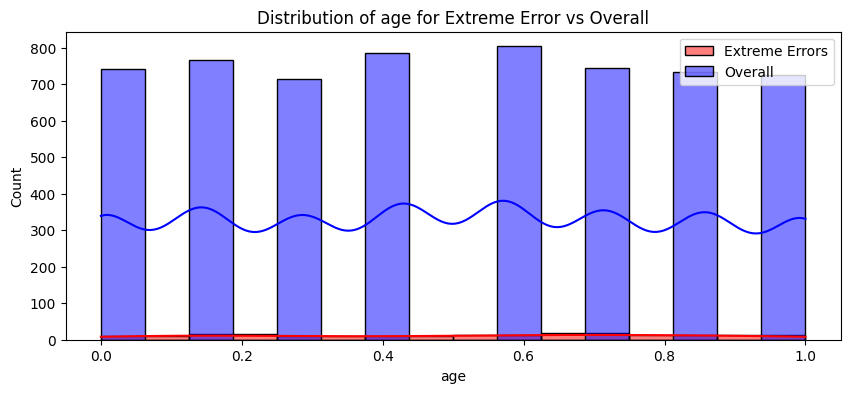

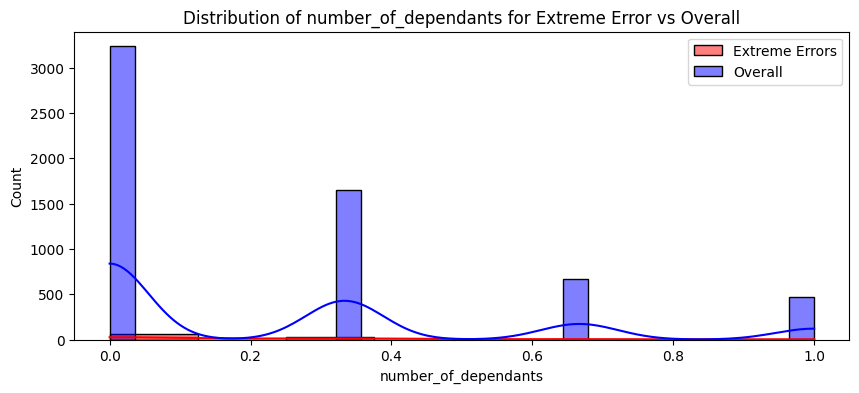

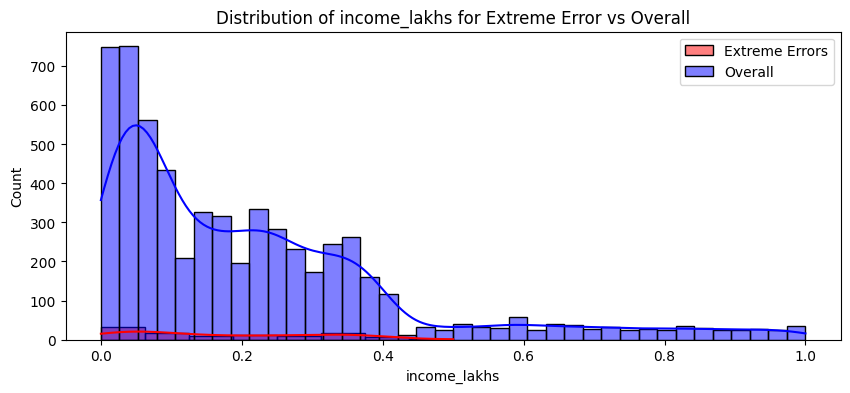

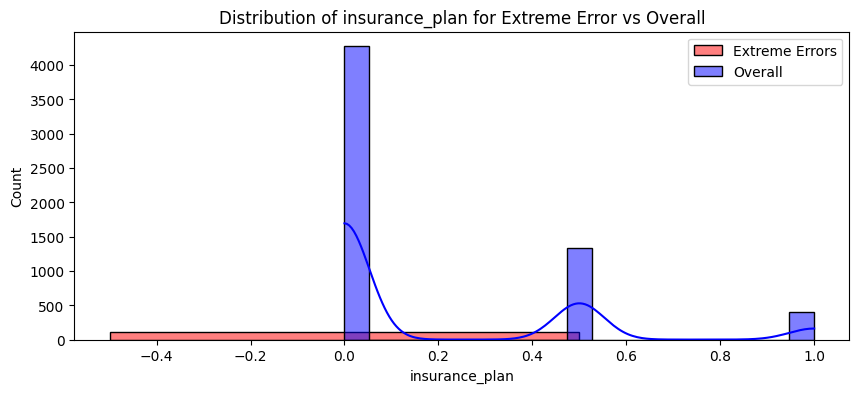

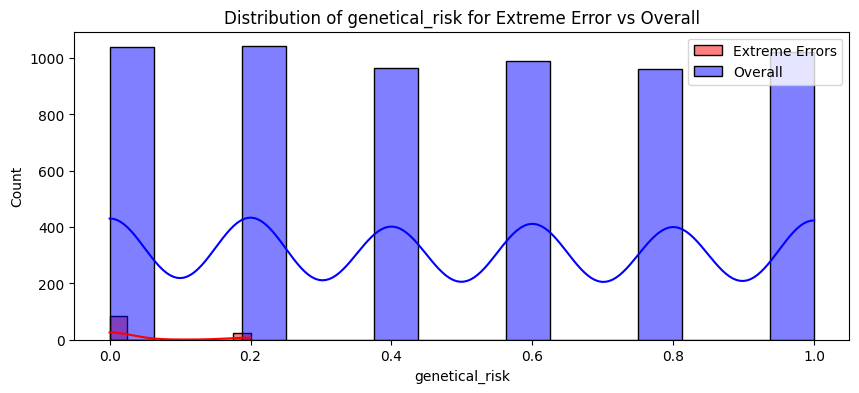

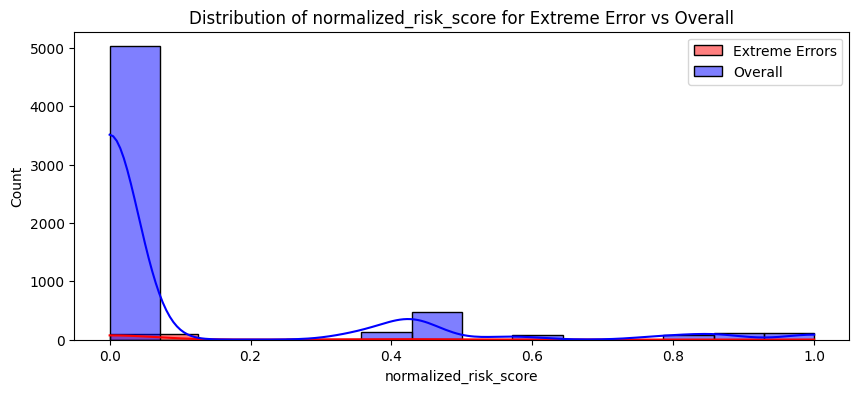

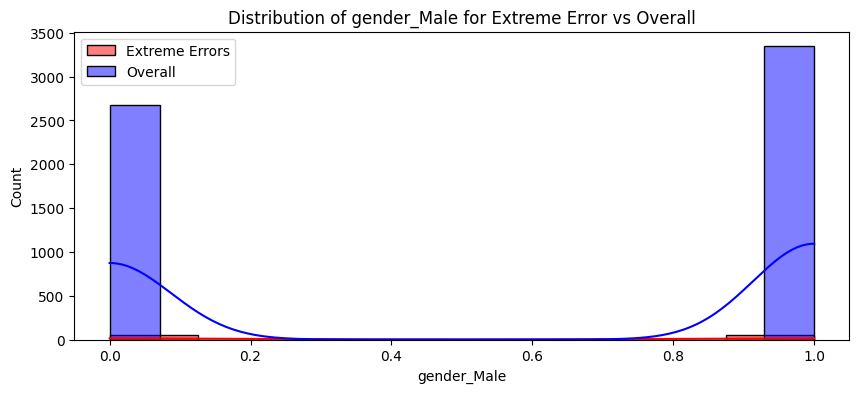

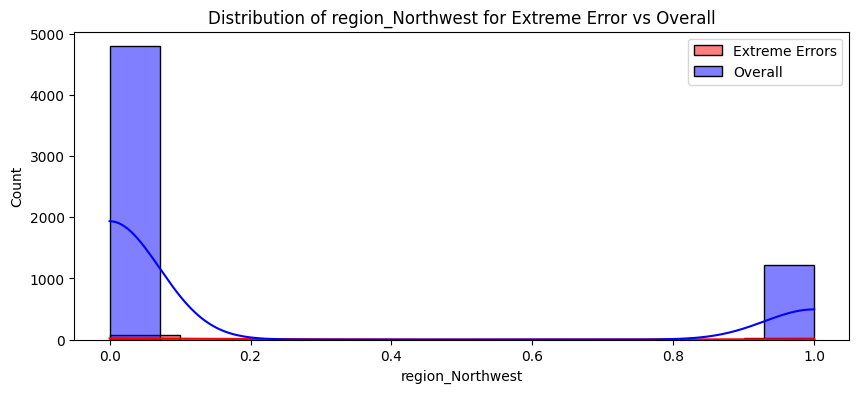

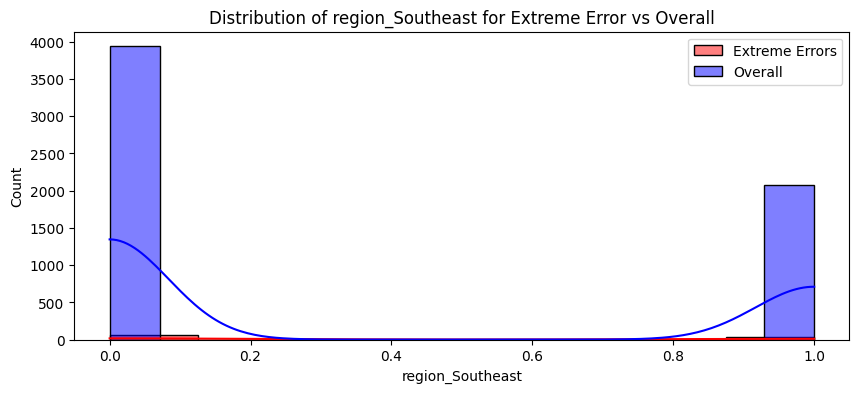

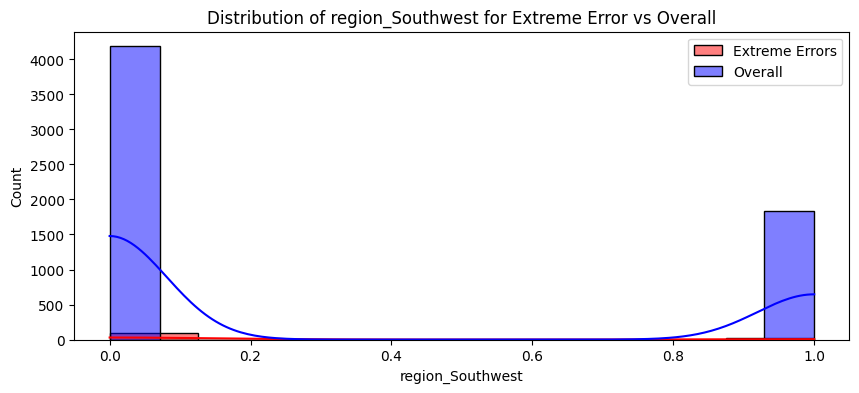

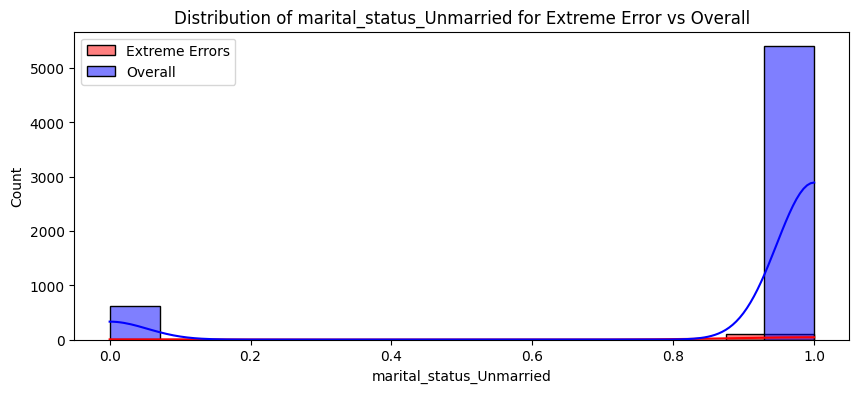

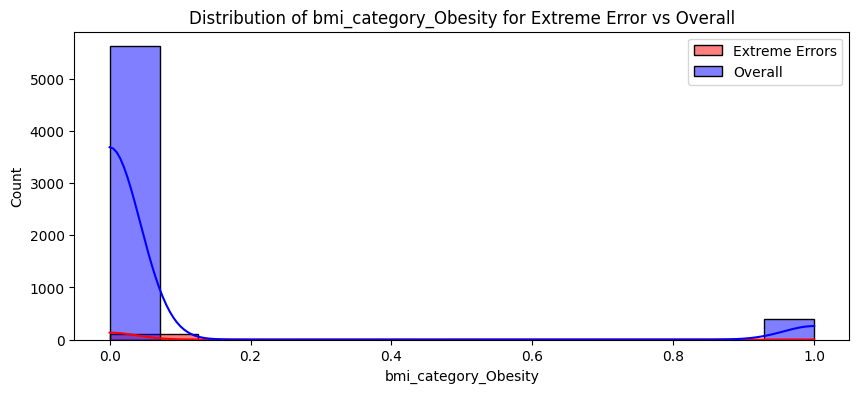

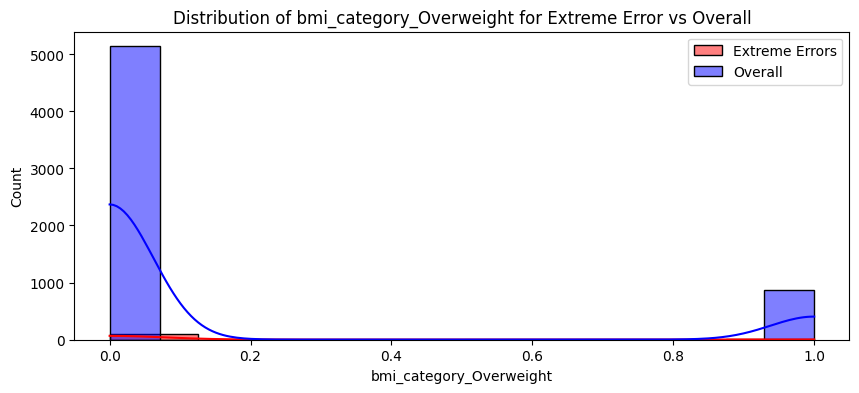

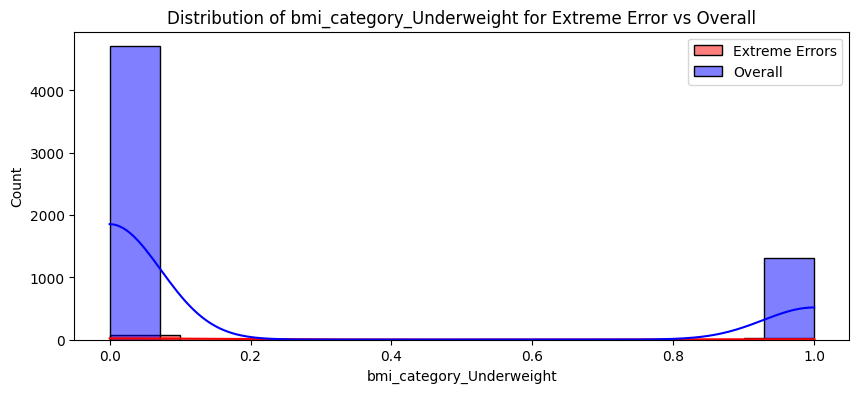

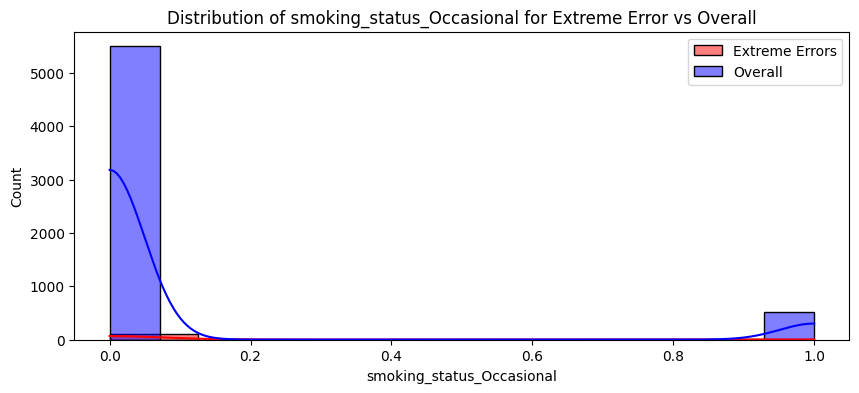

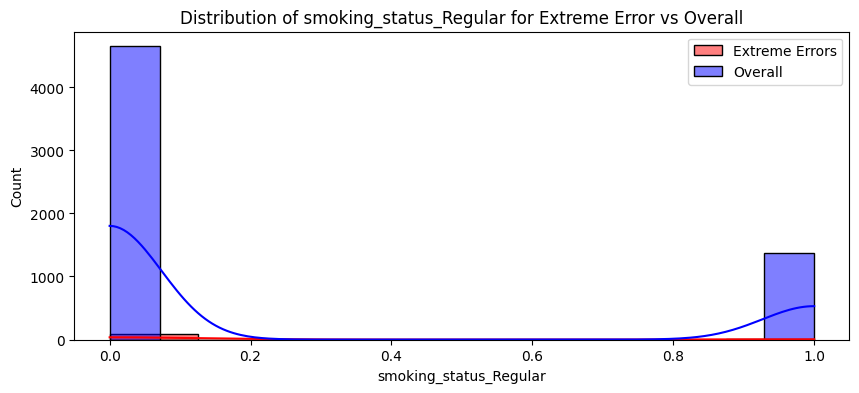

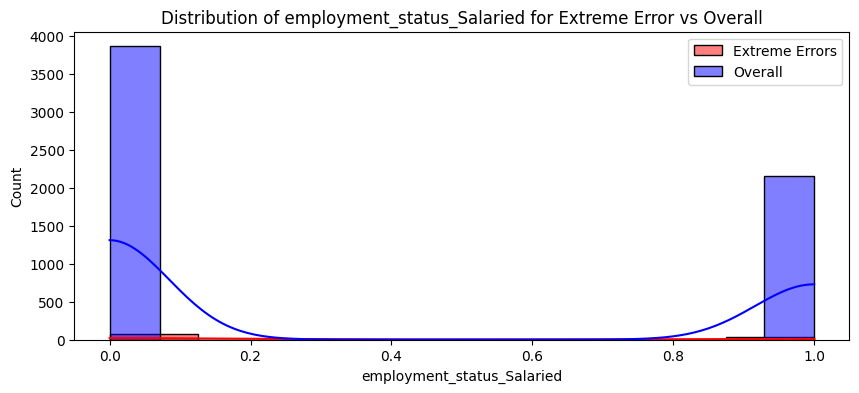

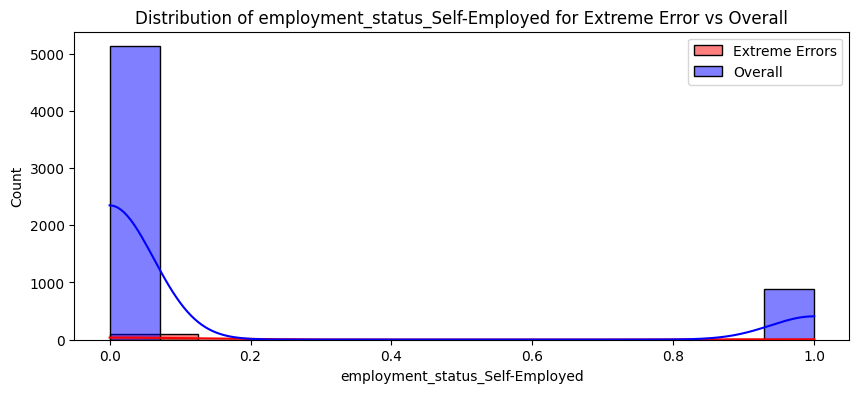

In [119]:
for feature in X_test.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(extreme_error_df[feature],color='red',label='Extreme Errors',kde=True)
    sns.histplot(X_test[feature],color='blue', label='Overall',alpha=0.5,kde=True)
    plt.legend()
    plt.title(f"Distribution of {feature} for Extreme Error vs Overall")
    plt.show()

<Axes: xlabel='age', ylabel='Count'>

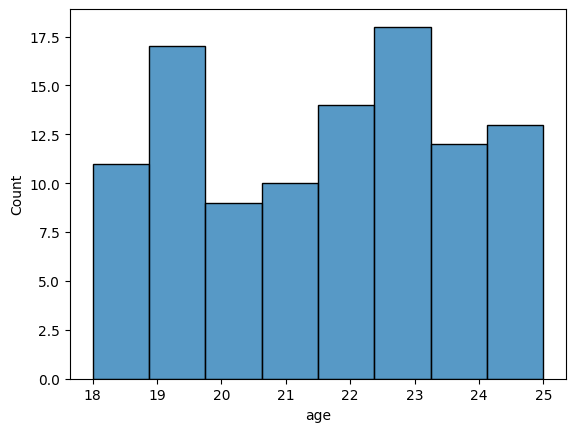

In [120]:
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_error_df[cols_to_scale])
df_reversed
sns.histplot(df_reversed['age'])

In [121]:
df_reversed['age'].quantile(0.99)

np.float64(25.0)

#### Export Model

In [127]:
import joblib

In [136]:
joblib.dump(best_model,"../artifacts/model_young.pkl")
scaler_with_cols = {
    'scaler' : scaler,
    'cols_to_scale' : cols_to_scale
}
joblib.dump(scaler_with_cols,"../artifacts/scaler_young.pkl")

['../artifacts/scaler_young.pkl']

In [128]:
scaler_with_cols = {
    'scaler' : MinMaxScaler(),
    'cols_to_scale' : cols_to_scale
}
cols_to_scale

['age',
 'income_level',
 'income_lakhs',
 'insurance_plan',
 'number_of_dependants',
 'genetical_risk']